## Spam detection

##### Apply NLP techniques to identify whether a message is SPAM or not

#### 1) Import Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SPAM text message 20170820 - Data.csv')
df.head(20)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


#### 2) Perform Basic EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [4]:
#checking missing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [5]:
#Check duplicate values
df.duplicated().sum()

np.int64(415)

In [6]:
#Remove Duplicate
df = df.drop_duplicates(keep = 'first')

In [7]:
label_type = list(df['Category'].unique())
print(f'Types of Category in the dataset: {label_type}')

Types of Category in the dataset: ['ham', 'spam']


#### 3) Check for class imbalance

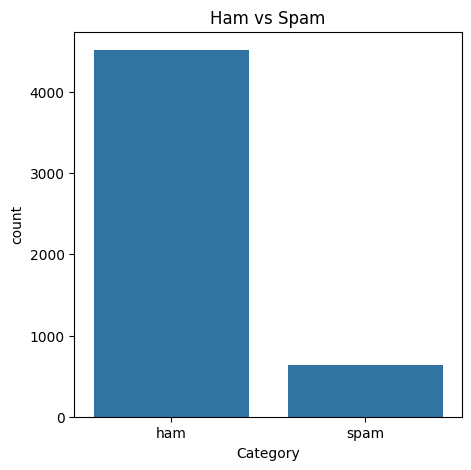

In [8]:
plt.figure(figsize=(5,5))
sns.countplot(x='Category',data=df)
plt.title('Ham vs Spam')
plt.show()

In [9]:
# Encode ham: 0 and spam: 1
df['Category'] = df['Category'].replace({'ham': 0, 'spam': 1})

In [10]:
df.head(5)

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


##### The data is imbalanced, but cannot use any resampling techniques. I can't risk applying either downsampling or oversampling.

#### 4) Text Pre-processing

In [11]:
import nltk
from nltk.corpus import stopwords

# Downloading stopwords and tokenizer from NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaku\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shaku\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shaku\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
import string
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def text_preprocessing(text):

    # STEP 1) Transform the text into lowercase
    text = text.lower()

    # STEP 2) Tokenization
    text = nltk.word_tokenize(text)


    # STEP 3) Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    # STEP 4) Removing punctuation and stopword
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    # STEP 5) Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(stemmer.stem(i))
        
    # Join the processed tokens back into a single string
    return " ".join(y)

In [13]:
df['Transformed_Message'] = df['Message'].apply(text_preprocessing)

In [14]:
df.head(5)

,Category,Message,Transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


#### 5) Text visualization

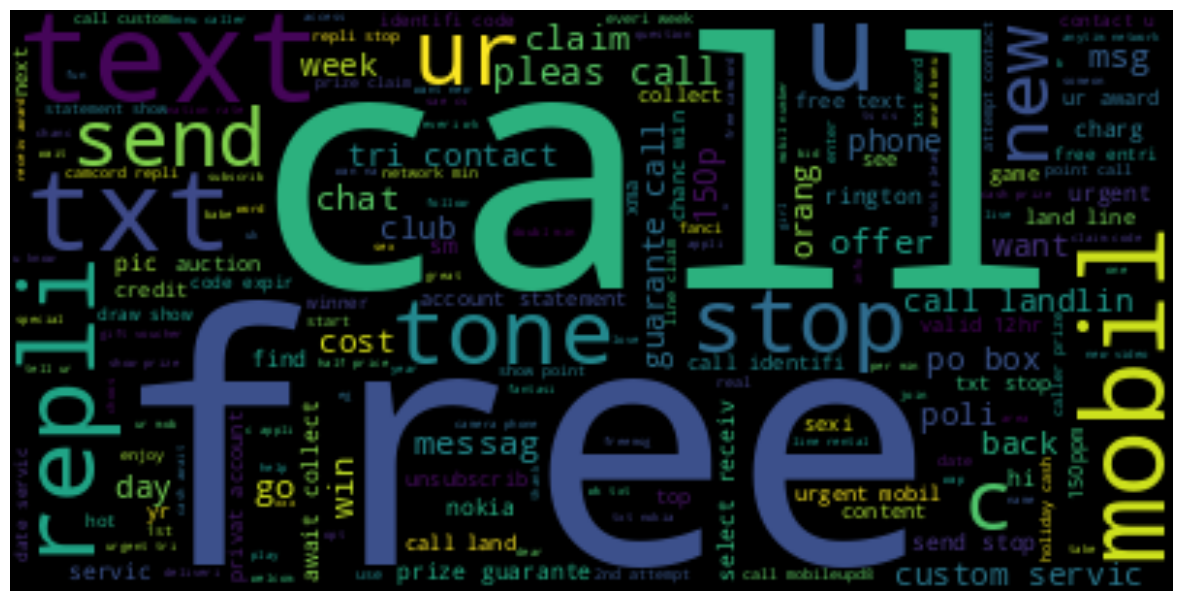

In [16]:
from wordcloud import WordCloud

spam_wc = WordCloud().generate(df[df['Category'] == 1]['Transformed_Message'].str.cat(sep = " "))
plt.figure(figsize= (15, 15))
plt.imshow(spam_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

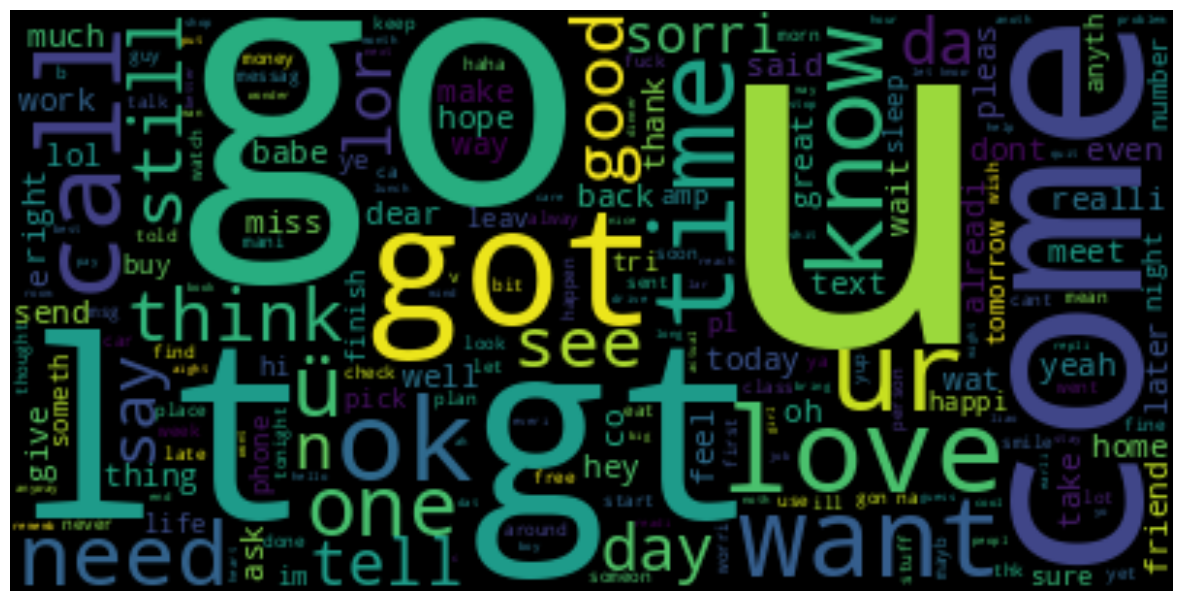

In [17]:
ham_wc = WordCloud().generate(df[df['Category'] == 0]['Transformed_Message'].str.cat(sep = " "))
plt.figure(figsize= (15, 15))
plt.imshow(ham_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

#### 6) Text Vectorization

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid = TfidfVectorizer(max_features = 3000)

x = tfid.fit_transform(df['Transformed_Message']).toarray()
y = df['Category'].values

#### 7) Train and Test Split

In [21]:
from keras_preprocessing.text import Tokenizer

num_words = 10000
max_text_length = 200

tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(df['Message'])

In [22]:
word_count = 50
keys = list(tokenizer.word_index.keys())[:word_count]
values = list(tokenizer.word_index.values())[:word_count]
list(zip(keys, values))

[('i', 1),
 ('to', 2),
 ('you', 3),
 ('a', 4),
 ('the', 5),
 ('u', 6),
 ('and', 7),
 ('in', 8),
 ('is', 9),
 ('me', 10),
 ('my', 11),
 ('for', 12),
 ('your', 13),
 ('it', 14),
 ('of', 15),
 ('have', 16),
 ('that', 17),
 ('on', 18),
 ('call', 19),
 ('2', 20),
 ('are', 21),
 ('now', 22),
 ('so', 23),
 ('but', 24),
 ('not', 25),
 ('at', 26),
 ('can', 27),
 ('or', 28),
 ("i'm", 29),
 ('do', 30),
 ('be', 31),
 ('get', 32),
 ('will', 33),
 ('just', 34),
 ('if', 35),
 ('with', 36),
 ('we', 37),
 ('no', 38),
 ('ur', 39),
 ('this', 40),
 ('up', 41),
 ('gt', 42),
 ('lt', 43),
 ('4', 44),
 ('how', 45),
 ('go', 46),
 ('when', 47),
 ('from', 48),
 ('ok', 49),
 ('out', 50)]

In [23]:
from keras_preprocessing.sequence import pad_sequences
import numpy as np
np.unicode_ = np.str_

sequences = tokenizer.texts_to_sequences(df['Message'])

# As a result, the text under the following index was converted to a vector
index = 6 
print(df['Message'][index])
print(sequences[index])

# Standardization of the number of elements in a vector
X = pad_sequences(sequences, maxlen=max_text_length)  
y = df['Category'].copy()

Even my brother is not like to speak with me. They treat me like aids patent.
[214, 11, 631, 9, 25, 55, 2, 392, 36, 10, 106, 659, 10, 55, 4008, 4009]


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
print(f'Training sample size: {len(X_train)}')
print(f'Test sample size: {len(X_test)}')

Training sample size: 4125
Test sample size: 1032


#### 8) Creating and training a reccurent model (LSTM)

In [25]:
from tensorflow import keras
from keras.models import Sequential 
from keras.layers import Dense, BatchNormalization, Embedding, LSTM
from keras import callbacks

model = Sequential()
model.add(Embedding(num_words, 64, input_length=max_text_length))
model.add(LSTM(3, return_sequences=True))
model.add(LSTM(5, return_sequences=True))
model.add(BatchNormalization())
model.add(LSTM(12))
model.add(Dense(1, activation='sigmoid'))

c:\AI_ML\ML_VS\NLP_Capstone\myenv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
callbacks = [
    callbacks.EarlyStopping(monitor='loss', min_delta=0.01, patience=10, verbose=1),  
    callbacks.ReduceLROnPlateau(monitor='loss', factor=0.1, min_delta=0.01, min_lr=1e-10, patience=4, verbose=1, mode='auto')
]

In [ ]:
model.compile(metrics=['Accuracy'], loss='binary_crossentropy', optimizer='Adam')

In [ ]:
history = model.fit(X_train, y_train, batch_size=50, epochs=10, validation_split=0.2,  callbacks=callbacks)

#### 9) Model Evaluation

In [ ]:
plt.figure(figsize=(24, 8))
plt.title('Visualization of the LSTM learning process', fontsize=14)
plt.plot(history.history['Accuracy'], label='The fraction of correct answers on the training set') 
plt.plot(history.history['val_Accuracy'], label='The fraction of correct answers of the validation set')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('The fraction of correct answers', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [ ]:
print(f'Metric on test: {model.evaluate(X_test, y_test)}')
print(f'Metric on train: {model.evaluate(X_train, y_train)}')

In [ ]:
model.summary()

In [ ]:
import joblib

# Dump the trained Keras model
joblib.dump(model, 'model.pkl')

# Dump the tokenizer as well, as it's needed for preprocessing new input
joblib.dump(tokenizer, 'tokenizer.pkl')